# AddressBlock augmentatie

De map `AddressBlock examples/` bevat 42 echte handgeschreven adresfoto's. Te weinig om mee te trainen. Met **Albumentations** maken we hier 20 varianten per afbeelding van → ~840 beelden met realistische camera-variatie (lichte rotatie, perspectief, belichting, JPEG-ruis, lichte blur). Output gaat naar `AddressBlock examples_aug/`, originelen blijven onaangeraakt.

In [1]:
## --- Dependencies ---
!pip install -q albumentations opencv-python-headless matplotlib

import os, glob, random
import numpy as np
import cv2
import albumentations as A
import matplotlib.pyplot as plt

# Paden relatief aan deze notebook
PROJECT_ROOT = os.path.abspath(os.getcwd())
SRC_DIR = os.path.join(PROJECT_ROOT, "AddressBlock examples")
DST_DIR = os.path.join(PROJECT_ROOT, "AddressBlock examples_aug")

print(f"Source: {SRC_DIR}")
print(f"Output: {DST_DIR}")

Source: c:\Users\karol\OneDrive\Bureaublad\HHS\Jaar 3 Semester 6\Datalab\Prime_Vision\AddressBlock examples
Output: c:\Users\karol\OneDrive\Bureaublad\HHS\Jaar 3 Semester 6\Datalab\Prime_Vision\AddressBlock examples_aug


In [2]:
def build_augmenter():
    """Moderate preset: realistische camera-variatie, tekst blijft leesbaar."""
    return A.Compose([
        # Geometrie - klein, leesbaar blijven
        A.Affine(rotate=(-4, 4), shear=(-3, 3), scale=(0.95, 1.05),
                 translate_percent=(0, 0.03), cval=255, p=0.9),
        A.Perspective(scale=(0.02, 0.05), pad_val=255, p=0.5),

        # Belichting / kleur
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7),
        A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=12, val_shift_limit=8, p=0.5),
        A.RandomGamma(gamma_limit=(88, 112), p=0.4),
        A.CLAHE(p=0.15),

        # Blur (camera beweging / focus)
        A.OneOf([
            A.MotionBlur(blur_limit=3),
            A.GaussianBlur(blur_limit=3),
            A.Defocus(radius=(1, 2)),
        ], p=0.35),

        # Sensorruis + JPEG artefacten
        A.GaussNoise(var_limit=(5.0, 20.0), p=0.4),
        A.ISONoise(p=0.15),
        A.ImageCompression(quality_lower=65, quality_upper=92, p=0.6),
    ])

augmenter = build_augmenter()
print("Augmenter klaar.")

Augmenter klaar.


C:\Users\karol\AppData\Local\Temp\ipykernel_22412\525010514.py:5: UserWarning: Argument(s) 'cval' are not valid for transform Affine
  A.Affine(rotate=(-4, 4), shear=(-3, 3), scale=(0.95, 1.05),
C:\Users\karol\AppData\Local\Temp\ipykernel_22412\525010514.py:7: UserWarning: Argument(s) 'pad_val' are not valid for transform Perspective
  A.Perspective(scale=(0.02, 0.05), pad_val=255, p=0.5),
C:\Users\karol\AppData\Local\Temp\ipykernel_22412\525010514.py:23: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.4),
C:\Users\karol\AppData\Local\Temp\ipykernel_22412\525010514.py:25: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=65, quality_upper=92, p=0.6),


In [3]:
def augment_folder(src_dir, dst_dir, n_per_image=20, seed=42):
    """Genereer n_per_image varianten per PNG/JPG in src_dir, schrijf naar dst_dir."""
    os.makedirs(dst_dir, exist_ok=True)
    paths = sorted(
        glob.glob(os.path.join(src_dir, "*.png")) +
        glob.glob(os.path.join(src_dir, "*.jpg")) +
        glob.glob(os.path.join(src_dir, "*.jpeg"))
    )
    if not paths:
        print(f"Geen afbeeldingen gevonden in {src_dir}")
        return

    aug = build_augmenter()
    total = 0
    for idx, p in enumerate(paths):
        stem = os.path.splitext(os.path.basename(p))[0]
        img_bgr = cv2.imread(p, cv2.IMREAD_COLOR)
        if img_bgr is None:
            print(f"  skip (kon niet lezen): {p}")
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Reproduceerbaar per afbeelding: zelfde seed per run → zelfde uitkomst
        rng_seed = seed + idx * 1000
        random.seed(rng_seed)
        np.random.seed(rng_seed)

        for n in range(n_per_image):
            out_rgb = aug(image=img_rgb)["image"]
            out_bgr = cv2.cvtColor(out_rgb, cv2.COLOR_RGB2BGR)
            out_path = os.path.join(dst_dir, f"{stem}_aug{n:02d}.png")
            cv2.imwrite(out_path, out_bgr)
            total += 1
        print(f"  {stem}: {n_per_image} varianten geschreven")

    print(f"\nKlaar: {len(paths)} originelen -> {total} augmentaties in {dst_dir}")

print("augment_folder() klaar.")

augment_folder() klaar.


In [4]:
# Draai de augmentatie: 42 originelen x 20 varianten = 840 afbeeldingen
augment_folder(SRC_DIR, DST_DIR, n_per_image=20, seed=42)

C:\Users\karol\AppData\Local\Temp\ipykernel_22412\525010514.py:5: UserWarning: Argument(s) 'cval' are not valid for transform Affine
  A.Affine(rotate=(-4, 4), shear=(-3, 3), scale=(0.95, 1.05),
C:\Users\karol\AppData\Local\Temp\ipykernel_22412\525010514.py:7: UserWarning: Argument(s) 'pad_val' are not valid for transform Perspective
  A.Perspective(scale=(0.02, 0.05), pad_val=255, p=0.5),
C:\Users\karol\AppData\Local\Temp\ipykernel_22412\525010514.py:23: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.4),
C:\Users\karol\AppData\Local\Temp\ipykernel_22412\525010514.py:25: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=65, quality_upper=92, p=0.6),


  real-hw-000000: 20 varianten geschreven
  real-hw-000001: 20 varianten geschreven
  real-hw-000002: 20 varianten geschreven
  real-hw-000003: 20 varianten geschreven
  real-hw-000004: 20 varianten geschreven
  real-hw-000005: 20 varianten geschreven
  real-hw-000006: 20 varianten geschreven
  real-hw-000007: 20 varianten geschreven
  real-hw-000008: 20 varianten geschreven
  real-hw-000009: 20 varianten geschreven
  real-hw-000010: 20 varianten geschreven
  real-hw-000011: 20 varianten geschreven
  real-hw-000012: 20 varianten geschreven
  real-hw-000013: 20 varianten geschreven
  real-hw-000014: 20 varianten geschreven
  real-hw-000015: 20 varianten geschreven
  real-hw-000016: 20 varianten geschreven
  real-hw-000017: 20 varianten geschreven
  real-hw-000018: 20 varianten geschreven
  real-hw-000019: 20 varianten geschreven
  real-hw-000020: 20 varianten geschreven
  real-hw-000021: 20 varianten geschreven
  real-hw-000022: 20 varianten geschreven
  real-hw-000023: 20 varianten ges

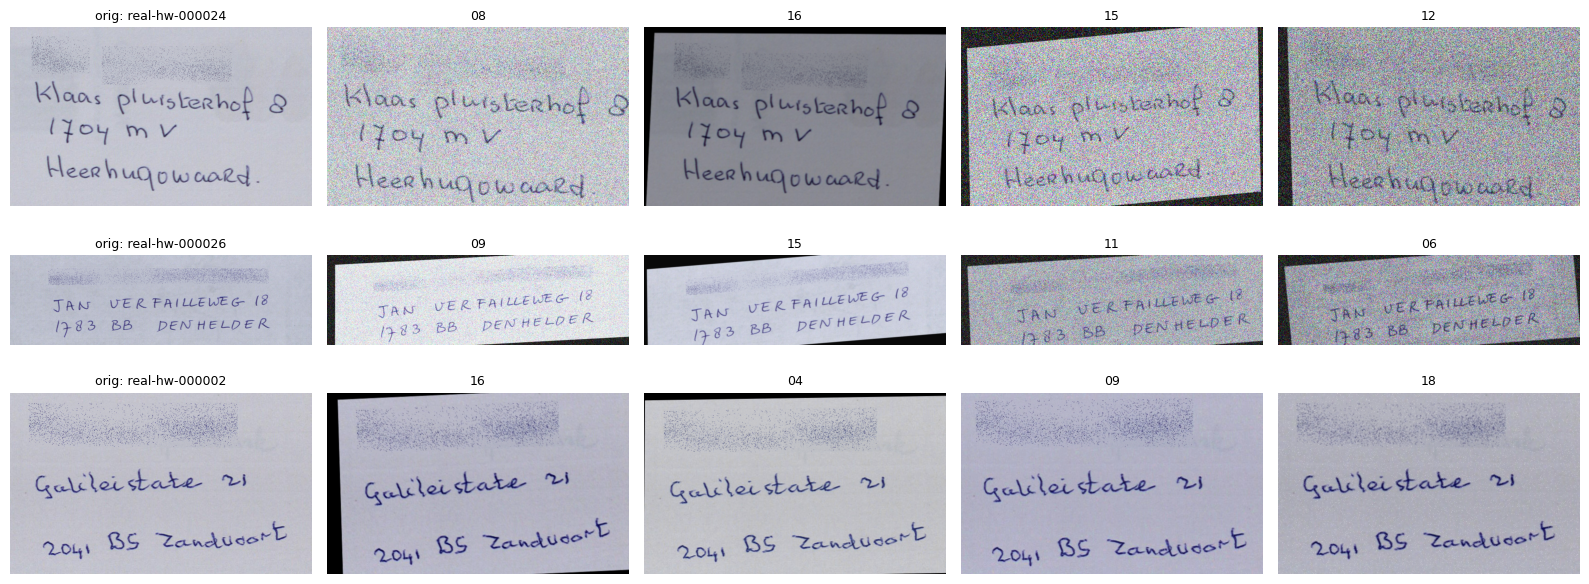

In [5]:
# Visuele check: 3 willekeurige originelen + 4 augmentaties per rij
random.seed(0)
originals = sorted(glob.glob(os.path.join(SRC_DIR, "*.png")))
samples = random.sample(originals, 3)

fig, axes = plt.subplots(3, 5, figsize=(16, 6))
for row, orig_path in enumerate(samples):
    stem = os.path.splitext(os.path.basename(orig_path))[0]
    orig = cv2.cvtColor(cv2.imread(orig_path), cv2.COLOR_BGR2RGB)
    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f"orig: {stem}", fontsize=9)
    axes[row, 0].axis("off")

    aug_paths = sorted(glob.glob(os.path.join(DST_DIR, f"{stem}_aug*.png")))
    pick = random.sample(aug_paths, min(4, len(aug_paths)))
    for col, ap in enumerate(pick, start=1):
        a = cv2.cvtColor(cv2.imread(ap), cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(a)
        axes[row, col].set_title(os.path.basename(ap).split("_aug")[-1].replace(".png", ""),
                                 fontsize=9)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()